In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported sucessfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")
print(f"matplotlib version:{plt.matplotlib.__version__}")

All libraries imported sucessfully
pandas version:2.2.2
sqlite3 version:2.6.0
matplotlib version:3.10.0



Importing sqlite3 library to work with SQLite databases

Importing pandas library for data analysis and DataFrame operations

Importing pyplot module from matplotlib for plotting graphs and charts

 Importing warnings module to handle warning messages

Ignoring all warning messages to keep output clean

Printing confirmation message after importing libraries

Displaying installed pandas version

Displaying matplotlib version

In [4]:
from google.colab import drive
# Importing the drive module from Google Colab
drive.mount('/content/drive')
# Mounting Google Drive to the Colab environment
# '/content/drive' is the folder where your Google Drive will appear

Mounted at /content/drive


In [5]:
df=pd.read_csv("/content/student_performance.csv")
print(f"Dataset loaded:{df.shape[0]}students,{df.shape[1]}")
print(f"Columns:{df.columns.tolist()}")
print("\nprint first 3 rows")
df.head(3)

Dataset loaded:30students,13
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

print first 3 rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


Step 1:Connect to(or crreate)a database file

In [6]:
conn=sqlite3.connect("college.db")
#conn is our connection to the database
cursor=conn.cursor()
#cursor is like pen to write the sql query
df.to_sql(
    'students' #table name
    ,conn,#creating this table inside college.db
    if_exists='replace', #if table already exists replace it
    index=False
    )
cursor.execute("SELECT COUNT(*)FROM students")
# Executing SQL query to count total number of rows in students table
count=cursor.fetchone()[0]
# Fetching the query result
# fetchone() returns one row as tuple
# [0] gets the first value from the tuple
print(f"Database 'college.db' craated successfully")
#Printing success message after database creation

print(f"Table student has {count }rows")
# Printing total number of rows present in students table

Database 'college.db' craated successfully
Table student has 30rows


SELECT column1, column2

FROM table_name

WHERE condition

GROUP BY column

HAVING group_condition

ORDER BY column DESC

LIMIT 10;

In [7]:
cursor.execute("PRAGMA table_info(students)")
# Executing SQLite command to get information about the structure of 'students' table

column_info=cursor.fetchall()

# Fetching all column details from the query result
# Stores the result as a list of tuples

print("Table Structure of 'Students'")
# Printing table heading

print(f"{'column Name':<25}{'Data Types':<12}")
# Printing formatted column headers
# <25 means left-align text within 25 spaces
# <12 means left-align text within 12 spaces

print("-" *38)
for col in column_info:
# Looping through each column detail in the table
  print(f"{col[1]:<25}{col[2]:<12}")
# col[1] -> Column name
# col[2] -> Data type of the column
# Printing column name and datatype in formatted style

Table Structure of 'Students'
column Name              Data Types  
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [8]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")
  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

1.find total number of students

2.display all columns and datatypesin pragma

3.display first five rows students

4.display student with marks>80

5.count number of male and female students


In [9]:
query1=""" select student_id ,name ,department,math_score,attendance_percentage
from students
LIMIT 10
"""

In [10]:
print("1.find total number of students")
run_query(query1)

1.find total number of students
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [11]:
query2 = """ SELECT name,department, math_score
FROM students
ORDER BY math_score DESC
LIMIT 5 """

In [12]:
query3=""" SELECT name,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department='computer science'
ORDER BY programming_score DESC
"""
result3=run_query(query3,"Top 5 students in computer science")



Top 5 students in computer science
Empty DataFrame
Columns: [name, math_score, science_score, programming_score, attendance_percentage]
Index: []


In [13]:
query4=""" SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage>90
AND department!="civil"
ORDER BY attendance_percentage DESC """
result4 = run_query(query4,"Query 4: High Attendance(>90%)Excluding Civil Dept")


Query 4: High Attendance(>90%)Excluding Civil Dept
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [14]:
query5="""
SELECT
department,
COUNT(*) AS total_students,
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score, -
ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
result5 = run_query(query5,"Query 5: Department ")


Query 5: Department 
      department  total_students  avg_math_score  avg_science_score  avg_programming_score  avg_attendance_percentage
Computer Science              13           85.62              84.46                  89.23                     -90.69
      Mechanical               6           71.00              76.50                  49.33                     -83.50
     Electronics               6           71.00              74.17                  61.50                     -80.33
           Civil               5           63.40              66.60                  40.60                     -74.60


In [15]:
query6="""
SELECT department, ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score,
ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
result6 = run_query(query6,"Query 6: Department")


Query 6: Department
      department  avg_math_score  avg_science_score  avg_programming_score  avg_attendance_percentage
Computer Science           85.62              84.46                  89.23                      90.69
      Mechanical           71.00              76.50                  49.33                      83.50
     Electronics           71.00              74.17                  61.50                      80.33
           Civil           63.40              66.60                  40.60                      74.60


In [16]:
query8 = """
SELECT
name,
department,
math_score + science_score + english_score + programming_score AS total_score
, attendance_percentage
FROM students
ORDER BY total_score DESC
LIMIT 10
"""
result8 = run_query(query8,"Query 8: Top 10 Students by Total Score")


Query 8: Top 10 Students by Total Score
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [17]:
dept_data ={
  'dept_code':['CS','EC','ME','CE'],
  'dept_name' :['Computer Science','Electronics','Mechanical','Civil'],
  'hod_name':['Dr.Subha','Dr.Vivek','Dr.Diwakar','Dr.Sharma'],
  'established':[1985,1970,1975,1990],
  'Location':['','','','']
}
dept_df = pd.DataFrame(dept_data)
dept_df.to_sql('departments', conn, if_exists='replace', index=False)
print(dept_df)

  dept_code         dept_name    hod_name  established Location
0        CS  Computer Science    Dr.Subha         1985         
1        EC       Electronics    Dr.Vivek         1970         
2        ME        Mechanical  Dr.Diwakar         1975         
3        CE             Civil   Dr.Sharma         1990         


In [18]:
query2 = """
SELECT department,
COUNT(*) AS student_count
FROM students
GROUP BY department
"""

dept_count_df = pd.read_sql_query(query2, conn)

print(dept_count_df)

         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6


# PRACTICE QUESTIONS:

1. How many students are from the Electronics Department?
2. What is the average attendance of female students?
3. who is the student with the lowest programming score?
4. How many students scored above 80 in math?
5. What  is the average total_score for students with attendance above 90%?

In [19]:
query15="""
SELECT COUNT(*) as Total_students
FROM students
WHERE department="Electronics"
"""
result15= run_query(query15,"Query 1: Students from Electronics Department")


Query 1: Students from Electronics Department
 Total_students
              6


In [20]:
query16="""
SELECT AVG(attendance_percentage)as avg_attendance
FROM students
WHERE gender="Female"
"""
result16=run_query(query16,"Query16:Average attendance of female students")


Query16:Average attendance of female students
 avg_attendance
      88.533333


In [21]:
query17="""
SELECT name,programming_score
FROM students
ORDER BY programming_score ASC
LIMIT 1
"""
result17=run_query(query17,"Query 17:Student with lowest programming score")


Query 17:Student with lowest programming score
        name  programming_score
Manoj Pandey                 38


In [22]:
query18="""
SELECT COUNT(*) as total_Students_above_80
FROM students
WHERE math_score>80
"""
result18=run_query(query18,"QUERY 18:Student scored about 80 in math")


QUERY 18:Student scored about 80 in math
 total_Students_above_80
                      11


In [23]:
query19="""
SELECT AVG(math_score + science_score + english_score + programming_score) as avg_total_score
FROM students
where attendance_percentage > 90
"""
result19=run_query(query19,"QUERY 19: Average total score for students with attendance above 90%")


QUERY 19: Average total score for students with attendance above 90%
 avg_total_score
           335.8


Day - 2 - Mini Project

SQLQUERY

Panel 1 data: avg math by department

Panel 2 data: student count by department

Panel 3 data: top 8 students by total score

Panel 4 data: gender-wise average attendance


Matplotlib
 Panel 1 (top-left): Avg Math by Department - BAR Chart

 Panel 2 (top-right): Student Count Pie Chart

 Panel 3 (bottom-left): Top 8 Students Horizontal Bar

 Panel 4 (bottom-right): Gender Avg Attendance Bar

Practice Questions
Question 1: Write a SQL query to find the average programming score for female students only.

Question 2: What is the difference between WHERE and HAVING? Write one example of each using the students table.

Question 3: Write a SQL query to find all departments where the average attendance is above 85%.

Question 4: What does pd.read_sql_query() return? What two arguments does it require?

Question 5: Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

In [24]:
query1 = """
SELECT department,
AVG(math_score) AS avg_math
FROM students
GROUP BY department
"""
result1=run_query(query1,"QUERY 1: Average Math Score by Department")




QUERY 1: Average Math Score by Department
      department  avg_math
           Civil 63.400000
Computer Science 85.615385
     Electronics 71.000000
      Mechanical 71.000000


In [25]:
query2="""
SELECT department,COUNT(*)
AS student_count
FROM students
GROUP BY department
"""
result2=run_query(query2,"QUERY2:Students count by department")


QUERY2:Students count by department
      department  student_count
           Civil              5
Computer Science             13
     Electronics              6
      Mechanical              6


In [26]:
query3 = """
SELECT name,
(math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
result3=run_query(query3,"QUERY 3:Top 8 students by total score")


QUERY 3:Top 8 students by total score
          name  total_score
    Ananya Das          371
   Tanvi Mehta          367
Akanksha Yadav          365
    Arjun Nair          356
   Divya Singh          356
Swati Kulkarni          354
     Amit Bose          336
    Suresh Rao          334


In [27]:
query4 = """
SELECT gender,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY gender
"""
result4=run_query(query4,"QUERY 4:Gender-wise average attendance")


QUERY 4:Gender-wise average attendance
gender  avg_attendance
Female       88.533333
  Male       80.466667


Text(0, 0.5, 'Average Math Score')

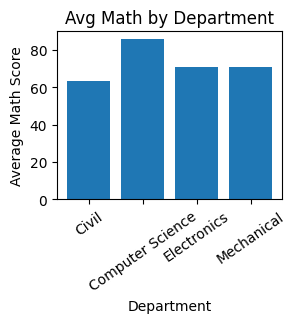

In [29]:
plt.subplot(2,2,1)
plt.bar(
    result1["department"],
    result1["avg_math"]
)
plt.xticks(rotation=35)

plt.title("Avg Math by Department")
plt.xlabel("Department")
plt.ylabel("Average Math Score")

In [ ]:
plt.subplot(2,2,2)

dept_count_df = pd.read_sql_query(query2, conn)

plt.pie(
    dept_count_df["student_count"],
    labels=dept_count_df["department"],
    autopct="%1.1f%%"
)

plt.title("Student Count by Department")

In [ ]:
plt.subplot(2,2,3)

result3 = pd.read_sql_query(query3, conn)

plt.bar(
    result3["name"],
    result3["total_score"]
)

plt.title("Top 8 Students by Total Score")
plt.xlabel("Total Score")
plt.ylabel("Student Name")
plt.xticks(rotation=45, ha='right')

In [ ]:
plt.subplot(2,2,4)
result4 = pd.read_sql_query(query4, conn)

plt.bar(
    result4["gender"],
    result4["avg_attendance"]
)
plt.xlabel("Gender")
plt.ylabel("Average Attendance")
plt.title("Gender-wise Average Attendance")

plt.tight_layout()
plt.show()

In [ ]:
query1 = """
SELECT AVG(programming_score) AS avg_programming_score
FROM students
WHERE gender = 'Female';
"""
result1=run_query(query1,"QUERY 1: Average Programming score")

In [ ]:
query2_where = """
SELECT *
FROM students
WHERE math_score > 80;
"""
result2=run_query(query2_where,"QUERY 2: WHERE")

query2_having = """
SELECT department,
AVG(math_score) AS avg_math
FROM students
GROUP BY department
HAVING AVG(math_score) > 75;
"""
result2=run_query(query2_having,"QUERY 2: HAVING")



In [ ]:
query3 = """
SELECT department,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""
result3=run_query(query3,"QUERY 3: Average attendance above 85%")

In [ ]:
query4 = """
SELECT *
FROM students
"""
result4=run_query(query4,"QUERY 4: pd.read_sql_query() return")

In [ ]:
query5 = """
SELECT department,
AVG(programming_score) AS avg_programming
FROM students
GROUP BY department;
"""
result5=run_query(query5,"QUERY 5: Modify Chart 1")


plt.bar(
    result5["department"],
    result5["avg_programming"]
)

plt.title("Avg Programming by Department")
plt.xlabel("Department")
plt.ylabel("Average Programming Score")

plt.xticks(rotation=15)

plt.show()

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Connect Database
conn = sqlite3.connect('college.db')

# =======================================================
# SQL QUERIES
# =======================================================

# Panel 1 data: Avg Math by Department
query1 = """
SELECT
    department,
    ROUND(AVG(math_score),1) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

avg_math_df = pd.read_sql_query(query1, conn)

# Panel 2 data: Student Count by Department
query2 = """
SELECT
    department,
    COUNT(*) AS student_count
FROM students
GROUP BY department
"""

student_count_df = pd.read_sql_query(query2, conn)

# Panel 3 data: Top 8 Students by Total Score
query3 = """
SELECT
    name,
    (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

top_students_df = pd.read_sql_query(query3, conn)

# Panel 4 data: Gender-wise Average Attendance
query4 = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage),1) AS avg_attendance
FROM students
GROUP BY gender
"""

attendance_df = pd.read_sql_query(query4, conn)

# =======================================================
# CREATE DASHBOARD
# =======================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# =======================================================
# Panel 1: Avg Math by Department
# =======================================================

ax1 = axes[0, 0]

bars1 = ax1.bar(
    avg_math_df['department'],
    avg_math_df['avg_math']
)

ax1.set_title("Average Math Score by Department")
ax1.set_xlabel("Department")
ax1.set_ylabel("Average Math Score")
ax1.set_ylim(0, 105)

ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Value labels
for bar in bars1:

    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center'
    )

# =======================================================
# Panel 2: Student Count Pie Chart
# =======================================================

ax2 = axes[0, 1]

colors = ['skyblue', 'lightgreen', 'orange', 'pink']

ax2.pie(
    student_count_df['student_count'],
    labels=student_count_df['department'],
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

ax2.set_title("Student Distribution by Department")

# =======================================================
# Panel 3: Top 8 Students Horizontal Bar
# =======================================================

ax3 = axes[1, 0]

top_students_df = top_students_df.sort_values(
    by='total_score'
)

bars3 = ax3.barh(
    top_students_df['name'],
    top_students_df['total_score']
)

ax3.set_title("Top 8 Students by Total Score")
ax3.set_xlabel("Total Score")

ax3.grid(axis='x', linestyle='--', alpha=0.6)

# Score labels inside bars
for bar in bars3:
    width = bar.get_width()
    ax3.text(
        width - 20,
        bar.get_y() + bar.get_height()/2,
        f'{width}',
        va='center',
        color='white'
    )

# =======================================================
# Panel 4: Gender Avg Attendance
# =======================================================

ax4 = axes[1, 1]

bars4 = ax4.bar(
    attendance_df['gender'],
    attendance_df['avg_attendance']
)

ax4.set_title("Average Attendance by Gender")
ax4.set_xlabel("Gender")
ax4.set_ylabel("Attendance Percentage")
ax4.set_ylim(0, 105)

ax4.grid(axis='y', linestyle='--', alpha=0.6)

# Percentage labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}%',
        ha='center'
    )

# =======================================================
# Dashboard Title and Layout
# =======================================================

fig.suptitle(
    "Student Performance Dashboard",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()

# =======================================================
# Save Dashboard
# =======================================================

plt.savefig(
    "student_dashboard.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Dashboard saved successfully as 'student_dashboard.png'")